Project Report
Context-Aware Batting Performance Evaluation for The Hundred
1. Introduction
Traditional batting metrics such as runs scored and strike rate provide a limited view of performance, especially in modern formats like The Hundred, where innings are constrained to 100 balls and match pressure fluctuates rapidly. These traditional metrics fail to capture context, such as when runs are scored, how pressure is handled, and the cost of dot balls or dismissals.

This project develops a ball-based, context-aware batting evaluation system tailored specifically for The Hundred, using only publicly available ball-by-ball data. The model aims to measure true batting impact rather than raw output.

2. Objective
The objectives of this project are:

To evaluate batting performance beyond runs and strike rate

To adapt batting metrics specifically for The Hundred format

To fairly compare batting first and batting second using a unified pressure framework

To produce explainable, validated, and normalized batting ratings

To demonstrate model validity using visual analysis

3. Data Description
Source: Cricsheet ball-by-ball data

Granularity: One row per ball

Match Type: The Hundred (100 balls per innings)

Key Columns Used:
ball, innings, striker, batting_team,
runs_off_bat, extras, wides,
player_dismissed

All calculations are performed at ball level, avoiding over-based assumptions.

4. Methodology Overview
The batting evaluation pipeline follows four stages:

Ball-level feature engineering

Base batting performance metrics

Unified Pressure Index (UPI) for context adjustment

Normalization and validation

5. Batting Metrics Definition
5.1 Runs Impact Score (RIS)
Measures total runs scored by the batter.
Used as a reference metric, not the primary driver.

5.2 Boundary Impact Score (BIS)
Captures momentum-shifting shots.

Four → weight 1.5

Six → weight 2.0

This reflects the higher value of boundaries in a 100-ball format.

5.3 Dot Ball Cost (DBC)
Measures pressure absorbed through dot balls.

Dot balls are penalized, with higher penalties in tougher phases:

Powerplay → low penalty

Death phase → high penalty

This reflects ball scarcity in The Hundred.

5.4 Phase Difficulty Bonus (PDB)
Rewards runs scored in harder phases of the innings.

Powerplay → baseline

Middle → moderate boost

Death → highest boost

This ensures that late-innings scoring is valued more than early accumulation.

5.5 Dismissal Penalty (DP)
Penalizes dismissals based on match phase.

Early dismissal → high cost

Death-phase dismissal → lower cost

This captures the opportunity cost of losing a wicket in a short format.

6. Base Batting Rating
The base batting rating combines all skill components without context:

Base Batting Rating
=
(
P
D
B
+
8
×
B
I
S
)
−
(
6
×
D
B
C
)
−
(
D
P
)
Base Batting Rating=(PDB+8×BIS)−(6×DBC)−(DP)
This answers:

“How well did the batter convert balls into value, ignoring match pressure?”

7. Unified Pressure Index (UPI)
Why UPI Is Needed
Batting first and batting second involve different types of pressure:

Batting first → uncertainty and tempo-setting pressure

Batting second → target and required run-rate pressure

Instead of assuming one innings is harder, pressure is measured explicitly.

UPI Construction
Batting second:
Pressure is measured using required runs per ball relative to match average.

Batting first:
Pressure is measured using current run rate vs match average, capturing slow starts or recovery situations.

UPI is bounded between 0.8 and 1.3:

UPI > 1 → high pressure

UPI < 1 → low pressure

This creates a single pressure scale applicable to both innings.

8. Final Batting Rating
The final batting rating incorporates pressure symmetrically:

Batting Match Rating
=
Base Batting Rating
×
Batter UPI
Batting Match Rating=Base Batting Rating×Batter UPI
This ensures:

No artificial bias toward batting first or second

Performance is rewarded only when executed under pressure

9. Normalization (0–100 Scale)
To improve interpretability, batting ratings are normalized using min–max scaling:

100 → Best batting performance in the match

0 → Lowest impact performance

Normalization preserves ranking while making results dashboard-ready.

10. Model Validation Using Visual Analysis
Several plots were created to validate the model:

10.1 Batting Rating Leaderboard
Confirms face validity using cricket intuition

10.2 Runs vs Batting Rating
Shows correlation without redundancy

Batters with similar runs can have different ratings

10.3 Pressure vs Batting Rating
Confirms that high-pressure performances are rewarded

10.4 Component Breakdown
Demonstrates explainability of each rating

Shows why a batter ranked high or low

10.5 Batting First vs Second Distribution
Confirms balanced treatment of both innings

No systemic skew detected

These visuals collectively establish model validity and fairness.

11. Key Insights
Batting impact in The Hundred cannot be captured by runs or strike rate alone.

Pressure-aware evaluation reveals hidden value in low-run, high-impact innings.

Dot balls and dismissals carry significant cost in ball-limited formats.

Unified pressure modeling removes innings-based bias.

The model is explainable, extensible, and analytically sound.

12. Limitations & Future Scope
Limitations

No batter quality or bowler quality adjustment

Single-match focus

Future Enhancements

Tournament-level aggregation

Win-probability impact per ball

Batter role classification (anchor, finisher, accelerator)

Integration with bowling metrics to compute Match MVP Index

13. Tools & Technologies
Python (Pandas, NumPy, Matplotlib)

Google Colab

Cricsheet ball-by-ball data

Power BI (for downstream visualization)

14. Conclusion
This project successfully demonstrates a context-aware batting evaluation framework for The Hundred, balancing scoring output, pressure handling, and risk management. By combining ball-level analysis with a Unified Pressure Index, the model provides a fair, explainable, and modern assessment of batting performance, suitable for professional cricket analytics.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("1252701.csv")


Basic Ball-Level Features

In [ ]:
# Runs scored by batter
df["runs"] = df["runs_off_bat"]

# Legal ball faced by batter
# Wides do NOT count as balls faced
df["legal_ball"] = df["wides"].isna().astype(int)
#Wides ≠ ball faced
#No-balls = ball faced (correct here)


Phase Classification (Hundred-Specific)

In [ ]:
def get_phase_hundred(ball):
    ball_no = int(ball)
    if ball_no <= 25:
        return "PP"
    elif ball_no <= 80:
        return "Middle"
    else:
        return "Death"

df["phase"] = df["ball"].apply(get_phase_hundred)
#Runs at the death are harder
#Dots at the death are more damaging

 CORE BATTING METRICS
🔹 Metric 1: Runs Impact Score (RIS)
What it measures:
Raw scoring output (baseline).

In [ ]:
RIS = (
    df.groupby("striker")["runs"]
    .sum()
    .rename("RIS")
)


 Metric 2: Boundary Impact Score (BIS)
Why:
Boundaries release pressure and spike momentum.

Weights:

Four → 1.5

Six → 2.0

In [ ]:
df["boundary_value"] = np.select(
    [df["runs"] == 4, df["runs"] == 6],
    [1.5, 2.0],
    default=0
)

BIS = (
    df.groupby("striker")["boundary_value"]
    .sum()
    .rename("BIS")
)


Metric 3: Dot Ball Cost (DBC)
Why:
Dots are expensive in a 100-ball game.

Phase-weighted penalties:

PP → 0.8

Middle → 1.0

Death → 1.3

In [ ]:
df["dot_ball"] = (
    (df["runs"] == 0) &
    (df["legal_ball"] == 1)
).astype(int)

phase_dot_penalty = {"PP":0.8, "Middle":1.0, "Death":1.3}

df["dot_cost"] = (
    df["dot_ball"] * df["phase"].map(phase_dot_penalty)
)

DBC = (
    df.groupby("striker")["dot_cost"]
    .sum()
    .rename("DBC")
)
#Higher DBC = absorbed more pressure.

 Metric 4: Phase Difficulty Bonus (PDB)
Why:
Runs at the death are harder than early runs.

Weights:

PP → 1.0

Middle → 1.1

Death → 1.3

In [ ]:
phase_run_weight = {"PP":1.0, "Middle":1.1, "Death":1.3}

df["phase_run_value"] = (
    df["runs"] * df["phase"].map(phase_run_weight)
)

PDB = (
    df.groupby("striker")["phase_run_value"]
    .sum()
    .rename("PDB")
)


 Metric 5: Dismissal Penalty (DP)
Why:
Getting out early is extremely costly in The Hundred.

Phase-based penalties:

PP → 15

Middle → 12

Death → 8

In [ ]:
df["is_dismissed"] = (
    df["player_dismissed"] == df["striker"]
).astype(int)

dismissal_penalty = {"PP":15, "Middle":12, "Death":8}

df["dismissal_cost"] = (
    df["is_dismissed"] * df["phase"].map(dismissal_penalty)
)

DP = (
    df.groupby("striker")["dismissal_cost"]
    .sum()
    .rename("DP")
)


BASE BATTING RATING (NO CONTEXT YET)

In [ ]:
Base_Batting_Rating = (
    1.0 * PDB +
    8.0 * BIS -
    6.0 * DBC -
    1.0 * DP
)


UNIFIED PRESSURE INDEX (UPI)
Match Reference Rate

In [ ]:
match_rpb = df["runs"].sum() / df["legal_ball"].sum()
#Average runs per ball for the match.

 STEP 5B: Chase Pressure (Batting Second)

In [ ]:
first_innings_runs = df[df["innings"] == 1]["runs"].sum()

df["cum_runs_chase"] = (
    df[df["innings"] == 2]
    .groupby("batting_team")["runs"]
    .cumsum()
)

df["balls_remaining"] = 100 - df["ball"].astype(int)

df["rrb"] = (
    (first_innings_runs - df["cum_runs_chase"]) /
    df["balls_remaining"]
)
#Required runs per ball.

 Uncertainty Pressure (Batting First)

In [ ]:
df["current_rpb"] = (
    df.groupby("innings")["runs"]
    .cumsum() /
    df.groupby("innings")["legal_ball"]
    .cumsum()
)
#Slow starts
#Collapse recovery pressure

Unified Pressure Index (UPI)

In [ ]:
df["UPI"] = np.where(
    df["innings"] == 2,
    df["rrb"] / match_rpb,                          # chase pressure
    (match_rpb - df["current_rpb"]) / match_rpb     # uncertainty pressure
)

df["UPI"] = df["UPI"].clip(0.8, 1.3)


Interpretation:

UPI > 1 → batter under pressure

UPI < 1 → batter comfortable

 Batter-Level UPI

In [ ]:
Batter_UPI = (
    df.groupby("striker")["UPI"]
    .mean()
)


FINAL BALANCED BATTING RATING

In [ ]:
Balanced_Batting_Rating = (
    Base_Batting_Rating *
    Batter_UPI
)
#No innings favoritism. Only measured pressure.

FINAL OUTPUT TABLE

In [ ]:
batting_result = pd.concat(
    [
        Balanced_Batting_Rating.rename("Batting_Match_Rating"),
        RIS, BIS, DBC, PDB, DP
    ],
    axis=1
).fillna(0).sort_values(
    "Batting_Match_Rating",
    ascending=False
)

batting_result


,Batting_Match_Rating,RIS,BIS,DBC,PDB,DP
striker,,,,,,
AE Jones,56.000000,33,9.5,4.0,33.0,15
ND Dattani,45.395696,34,8.0,4.8,34.0,15
E Jones,31.360000,47,13.5,16.8,47.0,15
DR Gibson,25.600000,8,3.0,0.0,8.0,0
DB Sharma,12.320000,28,4.5,5.6,28.0,15
GA Elwiss,12.160000,8,1.5,0.8,8.0,0
HC Knight,10.765373,21,4.5,4.8,21.0,15
AD Carr,10.720000,11,1.5,1.6,11.0,0
IECM Wong,10.560000,6,1.5,0.8,6.0,0


In [ ]:
batting_result["Raw_Batting_Rating"] = batting_result["Batting_Match_Rating"]


In [ ]:
min_score = batting_result["Raw_Batting_Rating"].min()
max_score = batting_result["Raw_Batting_Rating"].max()

batting_result["Batting_Rating_0_100"] = (
    (batting_result["Raw_Batting_Rating"] - min_score) /
    (max_score - min_score)
) * 100


In [ ]:
batting_result["Batting_Rating_0_100"] = (
    batting_result["Batting_Rating_0_100"].round(1)
)


In [ ]:
batting_result = batting_result.sort_values(
    "Batting_Rating_0_100",
    ascending=False
)

batting_result


,Batting_Match_Rating,RIS,BIS,DBC,PDB,DP,Raw_Batting_Rating,Batting_Rating_0_100
striker,,,,,,,,
AE Jones,56.000000,33,9.5,4.0,33.0,15,56.000000,100.0
ND Dattani,45.395696,34,8.0,4.8,34.0,15,45.395696,86.4
E Jones,31.360000,47,13.5,16.8,47.0,15,31.360000,68.4
DR Gibson,25.600000,8,3.0,0.0,8.0,0,25.600000,61.0
DB Sharma,12.320000,28,4.5,5.6,28.0,15,12.320000,43.9
GA Elwiss,12.160000,8,1.5,0.8,8.0,0,12.160000,43.7
HC Knight,10.765373,21,4.5,4.8,21.0,15,10.765373,41.9
AD Carr,10.720000,11,1.5,1.6,11.0,0,10.720000,41.9
IECM Wong,10.560000,6,1.5,0.8,6.0,0,10.560000,41.7


Batting Rating Leaderboard (Face Validity)
❓ Question it answers
Does the model rank batters in a way that looks sensible for this match?

What to expect
Top performers clearly separated

Tail-enders / low-impact innings at the bottom

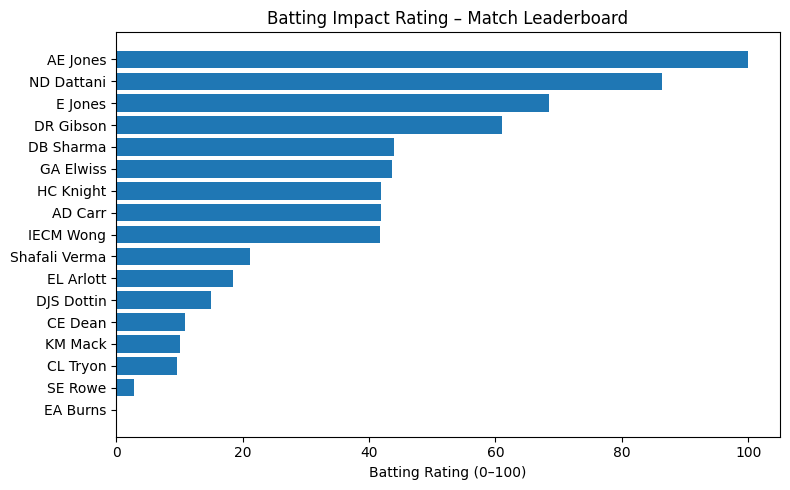

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(
    batting_result.index,
    batting_result["Batting_Rating_0_100"]
)
plt.xlabel("Batting Rating (0–100)")
plt.title("Batting Impact Rating – Match Leaderboard")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
#Raw Runs vs #Batting Rating (Independence Check)


What to expect
Positive trend (good batters score runs)

But clear dispersion (same runs ≠ same rating)

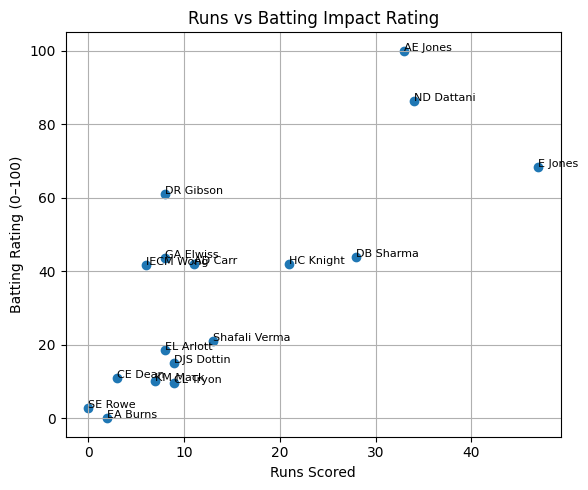

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    batting_result["RIS"],
    batting_result["Batting_Rating_0_100"]
)

for batter in batting_result.index:
    plt.text(
        batting_result.loc[batter,"RIS"],
        batting_result.loc[batter,"Batting_Rating_0_100"],
        batter,
        fontsize=8
    )

plt.xlabel("Runs Scored")
plt.ylabel("Batting Rating (0–100)")
plt.title("Runs vs Batting Impact Rating")
plt.grid(True)
plt.tight_layout()
plt.show()


Visual 5: Batting First vs Second Comparison (Bias Check)
❓ Question it answers
Did we accidentally favor one innings?

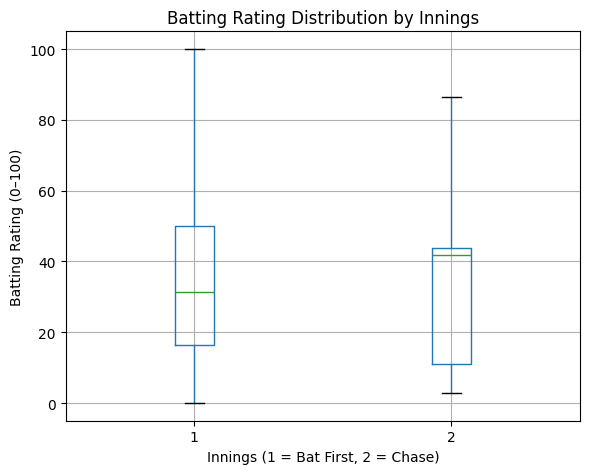

In [ ]:
innings_map = df.groupby("striker")["innings"].first()

ratings_df = batting_result.copy()
ratings_df["innings"] = innings_map

ratings_df.boxplot(
    column="Batting_Rating_0_100",
    by="innings",
    figsize=(6,5)
)

plt.suptitle("")
plt.title("Batting Rating Distribution by Innings")
plt.xlabel("Innings (1 = Bat First, 2 = Chase)")
plt.ylabel("Batting Rating (0–100)")
plt.tight_layout()
plt.show()


Validity signal:

Similar medians

No extreme skew
→ confirms UPI successfully balanced innings

 Visual 6: Strike Rate vs Rating (Bonus Validation)
❓ Question it answers
Is the model blindly rewarding fast scoring?

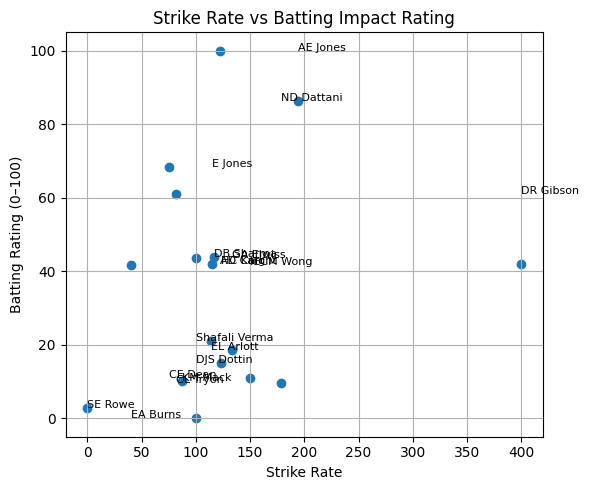

In [ ]:
balls_faced = (
    df.groupby("striker")["legal_ball"]
    .sum()
)

strike_rate = (batting_result["RIS"] / balls_faced) * 100

plt.figure(figsize=(6,5))
plt.scatter(
    strike_rate,
    batting_result["Batting_Rating_0_100"]
)

for batter in batting_result.index:
    plt.text(
        strike_rate[batter],
        batting_result.loc[batter,"Batting_Rating_0_100"],
        batter,
        fontsize=8
    )

plt.xlabel("Strike Rate")
plt.ylabel("Batting Rating (0–100)")
plt.title("Strike Rate vs Batting Impact Rating")
plt.grid(True)
plt.tight_layout()
plt.show()


Validity signal:
Fast but reckless innings shouldn’t always top the chart.